# ICePop tutorial

## 1. Extract metacells

In [ ]:
! icepop metacell \
    --h5ad ../data/TM_FACS/TM_FACS_cnt.h5ad \
    --outdir ../results/TM_FACS_mc \
    --save_name TM_FACS \
    --device cpu # or 'cuda' (default) to speed up the run

2026-03-26 20:24:23,732 - icepop.metacell - INFO - Max expression value: 31922356.0
2026-03-26 20:24:23,732 - icepop.metacell - INFO - Totol number of cells: 110824, target metacell number: 1478
2026-03-26 20:24:23,732 - icepop.metacell - INFO - Running MetaQ
=======Loading and Preprocessing Data=======
Data of 1 omics in total
data/TM_FACS/TM_FACS_cnt.h5ad loaded with shape [110824, 2815]
Target metacell number: 1478
======= Training Start =======
[Epoch 20] RNA: Loss Rec=0.7936 Loss Rec Q=0.8123 | Codebook: Loss C=0.0034     in 0s (~0s, 548.1/s) (~3:15, 1.3/s) in 37s (~59:19, 0.1/s)8/300 [3%] in 2:20 (~1:25:28, 0.1in 3:12 (~1:32:09, 0.in 3:22 (~1:33:30, 0.(~1:31:17, 0.(~1:30:35, 0.14/300 [5%] in 4:27 (~1:33:44, 0.in 4:57 (~1:33:31, 0.16/300 [5%] in 5:15 (~1:32:43, 0. ▂▄▆ 16/300 [5%] in 5:28 (~1:36:43, 0.(~1:32:56, 0.▅▃▁ 18/300 [6%] in 5:52 (~1:36:11, 0.(~1:35:50, 0.
[Epoch 40] RNA: Loss Rec=0.7782 Loss Rec Q=0.8007 | Codebook: Loss C=0.0030     (~1:34:03, 0.(~1:34:52, 0.(~1:33:59, 0.

## 2. Get association, mixture and influence diagnoistics

In [ ]:
! icepop association \
    --h5ad ../data/TM_FACS/TM_FACS_cnt.h5ad \
    --mc_assign ../results/TM_FACS_mc/mc_assign.csv \
    --magmaz ../data/magmaz/PASS_UC_deLange2017.genes.out \
    --sp mmusculus \
    --outdir ../results/TM_FACS_asso

2026-03-27 10:52:20,949 - icepop.association - INFO - Starting association analysis
2026-03-27 10:52:20,949 - icepop.association - INFO - Inputs: h5ad=data/TM_FACS/TM_FACS_cnt.h5ad, mc_assign=results/TM_FACS_mc/mc_assign.csv, magmaz=data/magmaz/PASS_UC_deLange2017.genes.out
2026-03-27 10:52:20,949 - icepop.association - INFO - Params: ct_key=cell_type, sp=mmusculus, n_perm=1000, q_thres=0.1, n_jobs=20
2026-03-27 10:52:20,949 - icepop.association - INFO - Loading h5ad and metacell assignment
2026-03-27 10:52:21,858 - icepop.association - INFO - Loaded adata: n_cells=110824, n_genes=22499
2026-03-27 10:52:21,859 - icepop.association - INFO - Number of cell_type: 120
2026-03-27 10:52:21,870 - icepop.association - INFO - Number of metacells 1433
2026-03-27 10:52:21,875 - icepop.association - INFO - Metacell sizes: min=1, median=75.0, max=12613
2026-03-27 10:52:22,629 - icepop.association - INFO - Loading precomputed metacell specificity scores
2026-03-27 10:52:22,789 - icepop.association -

## 3. Example visualization of associated subpopulations in enterocyte of epithelium of large intestine

In [ ]:
import scanpy as sc
import pandas as pd
from statsmodels.stats.multitest import multipletests
import numpy as np
import matplotlib.pyplot as plt
import mygene

In [ ]:
# utility fuctions for plotting
def plot_umap(
    adata, col,
    cmap='Reds', alpha=0.6, labelsize=15, size=80,
    palette=None, vmin=None, vmax=None,
    title=None, colorbar_label=None, outfile=None
):
    # determine if we use custom scaling
    use_limits = isinstance(vmin, (float, int)) and isinstance(vmax, (float, int))
    
    # generate the plot
    if palette:
        ax = sc.pl.umap(
            adata,
            color=col,
            show=False,
            palette=palette,
            vmin=vmin if use_limits else None,
            vmax=vmax if use_limits else None,
            alpha=alpha,
            size=size
        )
    else:
        ax = sc.pl.umap(
            adata,
            color=col,
            show=False,
            cmap=cmap,
            vmin=vmin if use_limits else None,
            vmax=vmax if use_limits else None,
            alpha=alpha,
            size=size
        )

    ax.set_xlabel('UMAP1', fontsize=labelsize)
    ax.set_ylabel('UMAP2', fontsize=labelsize)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    ax.set_xticks([]) 
    ax.set_yticks([])
    
    ax.tick_params(
        left=True, bottom=True, labelleft=True, labelbottom=True,
    )

    if colorbar_label is not None:
        fig = ax.figure
        for other_ax in fig.axes:
            if other_ax is not ax:
                other_ax.set_ylabel(colorbar_label, fontsize=labelsize)

    if not title:
        ax.set_title("")
    else:
        ax.set_title(title, fontsize=16)

    if outfile:
        plt.tight_layout()
        plt.savefig(outfile)
    else:
        plt.show()

def plot_opa_umap(
    adata, col,
    alpha=0.6, alpha_bg=0.1,
    labelsize=15, size=80,
    palette=None,
    title=None,
    outfile=None,
    bg_label="Not associated"
):

    if not pd.api.types.is_categorical_dtype(adata.obs[col]):
        raise ValueError("This function is for categorical columns only.")

    coords = adata.obsm["X_umap"]
    categories = adata.obs[col].cat.categories
    if palette is None:
        palette = sc.pl.palettes.default_20[:len(categories)]

    fig, ax = plt.subplots()

    for cat, color in zip(categories, palette):
        mask = adata.obs[col] == cat
        this_alpha = alpha_bg if cat == bg_label else alpha

        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c=color,
            s=size,
            alpha=this_alpha,
            label=cat
        )
    
    ax.set_xlabel('UMAP1', fontsize=labelsize)
    ax.set_ylabel('UMAP2', fontsize=labelsize)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        markerscale=1.5
    )

    if title:
        ax.set_title(title, fontsize=16)

    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, bbox_inches="tight")
    else:
        plt.show()


def umap_filter(
    adata,
    top=100.0, bottom=100.0,
    left=100.0, right=100.0
):
    X = adata.obsm["X_umap"]
    x, y = X[:, 0], X[:, 1]
    
    mask = (
        (x > np.percentile(x, 100 - left)) &
        (x < np.percentile(x, right)) &
        (y > np.percentile(y, 100 - bottom)) &
        (y < np.percentile(y, top))
    )
    n_remove = adata.shape[0] - mask.sum()
    print(f'{n_remove} cell removed')
    print("%.2f%% cells left" % (mask.sum() / adata.shape[0] * 100))
    return adata[mask, :].copy()

In [ ]:
# read in TM single-cell count data
adata = sc.read('../data/TM_FACS/TM_FACS_cnt.h5ad')

## normalize data
# add gene identifier column
adata.var['entrez'] = adata.var_names

# standard preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# read in metacell assignment file from the result folder
adata.obs['metacell'] = pd.read_csv('../results/TM_FACS_mc/mc_assign.csv', header=None, index_col=None)[0].values

In [ ]:
# read in Disease/trait-metacell type association table
mc_df = pd.read_csv("../results/TM_FACS_asso/metacell__trait-PASS_UC_deLange2017.csv")
# remove the column axis name ("mc_df")
mc_df.columns.name = None
# remove the index name ("metacell")
mc_df.index.name = None

# compute normalized cell-type frequencies per metacell
freq_df = pd.crosstab(adata.obs['cell_type'], adata.obs['metacell'])
freq_df = freq_df.div(freq_df.sum(0))

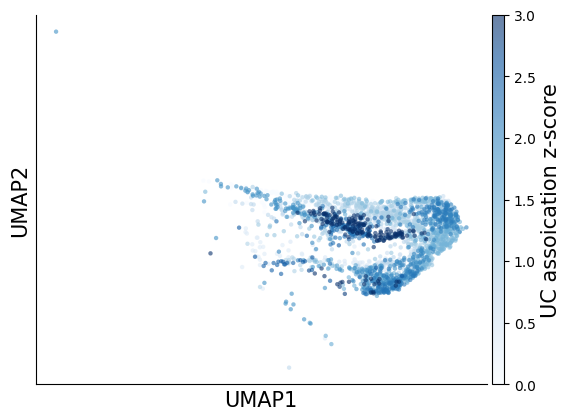

78 cell removed
96.93% cells left


In [33]:
ct = 'enterocyte of epithelium of large intestine'
trait = 'PASS_UC_deLange2017'
sub_adata = adata[adata.obs['cell_type'] == ct].copy()
mc_df = mc_df.set_index('metacell').copy()

# metacell purity adjusted fdr
metacells = mc_df.index.values
purity = freq_df.loc[ct, metacells].values
mc_p = mc_df['p'].values
p = mc_p[purity > 0]
pos_mcs = metacells[np.argwhere(purity > 0).ravel()]
w = purity[purity > 0]
w = w / w.sum() * w.size
q = multipletests(p / w, method='fdr_bh')[1]
mc2q = dict(zip(pos_mcs, q))

sub_adata.obs['mc_z'] = list(mc_df.loc[sub_adata.obs['metacell'], 'z'])
c_q = np.asarray([
    mc2q[mc] if mc in mc2q else 1.0
    for mc in sub_adata.obs['metacell']
])
sub_adata.obs['mc_discovery'] = np.where(c_q <= 0.1, 'Associated', 'Not associated')

plot_umap(sub_adata, 'mc_z', cmap='Blues', size=40, vmin=0, vmax=3, colorbar_label='UC assoication z-score', outfile=False)
sub_adata = umap_filter(sub_adata, right=99, bottom=99, left=99)

## 4. Example code to check influenced genes

In [ ]:
f = np.load('../results/TM_FACS_asso/dfbs__trait-PASS_UC_deLange2017.npz', allow_pickle=True)
cg_dfbs = pd.DataFrame(f['dfbs'], index=f['celltypes'], columns=f['genes'])
cg_dfbs.head()

,148398,26155,339451,84069,84808,9636,375790,401934,54991,254173,...,440836,113730,644186,1375,1120,23542,410,85358,49,11158
B cell,-0.000698,0.000099,-0.000119,0.004641,0.000697,-0.000375,-0.002066,0.004164,-0.002002,-0.004248,...,-0.007561,-0.003115,-0.001406,-0.000024,-0.000830,0.002289,0.003014,-0.002286,0.000099,0.000651
Bergmann glial cell,-0.000212,-0.000115,-0.000033,0.002057,0.000285,-0.000145,-0.000589,0.002017,-0.001139,-0.001832,...,-0.003262,-0.001348,-0.000572,0.000050,0.000562,-0.001538,0.000217,-0.000821,0.000089,0.000276
Brush cell of epithelium proper of large intestine,-0.000329,-0.000067,-0.000024,0.003957,0.000846,-0.000320,-0.000730,-0.000423,-0.002078,0.014648,...,0.007383,0.007187,0.004578,0.000039,0.000073,0.002044,0.003323,-0.002025,0.000158,0.000631
"CD4-positive, alpha-beta T cell",0.000076,0.000142,-0.000085,0.004314,0.000710,0.000087,-0.001922,0.003627,-0.000068,-0.003272,...,-0.005743,-0.004521,-0.001298,0.000047,0.000233,0.002013,0.002950,-0.002156,0.000118,0.000628
"CD8-positive, alpha-beta T cell",0.000036,0.000202,-0.000072,0.003866,0.000453,0.000134,-0.001791,0.002917,-0.000101,-0.002958,...,-0.006523,-0.002685,-0.001217,0.000026,0.000170,0.001773,0.002910,-0.001995,0.000097,0.000597


In [ ]:
cg_dfbs_long = cg_dfbs.reset_index().melt(
    id_vars='index',
    var_name='Entrez',
    value_name='Influence score'
)

cg_dfbs_long = cg_dfbs_long.rename(columns={'index': 'Cell type'})
cg_dfbs_long = cg_dfbs_long[cg_dfbs_long["Influence score"] != 0]

# assess assocaitions using influence score threshold calculated as
# 2/np.sqrt(n), n is number of genes included in the analysis
n = cg_dfbs.shape[1]
threshold = 2 / np.sqrt(n)

cg_dfbs_long["Associated"] = cg_dfbs_long["Influence score"].abs() > threshold

# add gene info
mg = mygene.MyGeneInfo()

gene_ids = cg_dfbs_long["Entrez"].astype(str).unique().tolist()

gene_info = mg.querymany(
    gene_ids,
    scopes="entrezgene",
    fields="symbol",
    species="human",
    as_dataframe=True
)

gene_map = gene_info[['symbol']]
gene_map.index.name = "Entrez"
gene_map = gene_map.reset_index()

cg_dfbs_long["Entrez"] = cg_dfbs_long["Entrez"].astype(str)
gene_map["Entrez"] = gene_map["Entrez"].astype(str)

cg_dfbs_final = cg_dfbs_long.merge(gene_map, on="Entrez", how="left")
cg_dfbs_final = cg_dfbs_final.rename(columns={"symbol": "Gene"})

# read in disease-cell association result
disease_cell_asso = pd.read_csv("../results/TM_FACS_asso/celltype__trait-PASS_UC_deLange2017.csv")
# merge FDR values to the cg_dfbs table
cg_dfbs_final = cg_dfbs_final.merge(
    disease_cell_asso[["cell_type", "q"]],
    left_on="Cell type",
    right_on="cell_type",
    how="left"
)

# finalize and add influence score rank
cg_dfbs_final = cg_dfbs_final.drop(columns=["cell_type"])
cg_dfbs_final = cg_dfbs_final.rename(columns={"q": "FDR"})
cg_dfbs_final = cg_dfbs_final.sort_values(by="Influence score", ascending=False)
cg_dfbs_final['Influence score rank'] = range(1, len(cg_dfbs_final) + 1)

cg_dfbs_final = cg_dfbs_final[
    [
        "Gene",
        "Entrez",
        "Cell type",
        "FDR",
        "Associated",
        "Influence score",
        "Influence score rank",
    ]
]

cg_dfbs_final.head()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


,Gene,Entrez,Cell type,FDR,Associated,Influence score,Influence score rank
664778,FAM162B,221303,pericyte cell,0.390928,True,1.547579,1
23939,PLA2G2E,30814,kidney interstitial fibroblast,0.203786,True,1.361099,2
1505745,PNMT,5409,pulmonary interstitial fibroblast,0.622059,True,1.224261,3
202039,TPO,7173,mucus secreting cell,0.999865,True,1.097588,4
40290,MATN1,4146,oligodendrocyte precursor cell,0.999865,True,1.062397,5
